# GPT-2 training loss

Renders the curve from `log/log.txt`, written by `train_gpt.py`.

Re-run the cells while a training job is going — it plots whatever exists so far.

In [11]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, sys
# gpt2 is pip-installed (-e .); the plotting helper lives in scripts/
REPO = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(REPO, 'scripts'))
import plot_loss as P

LOG = os.path.join(REPO, 'runs', 'log.txt')
data = P.read_log(LOG)
train_steps, train_loss, val_steps, val_loss = data
print(f'{len(train_steps)} train points, {len(val_steps)} val points')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
330 train points, 2 val points


## The curve

Blue is train (raw per-step behind a rolling mean), orange is validation.
The dashed line is OpenAI's released GPT-2 124M checkpoint evaluated on this
same FineWeb-EDU val split — comparable only because we use the same data and
the same BPE.

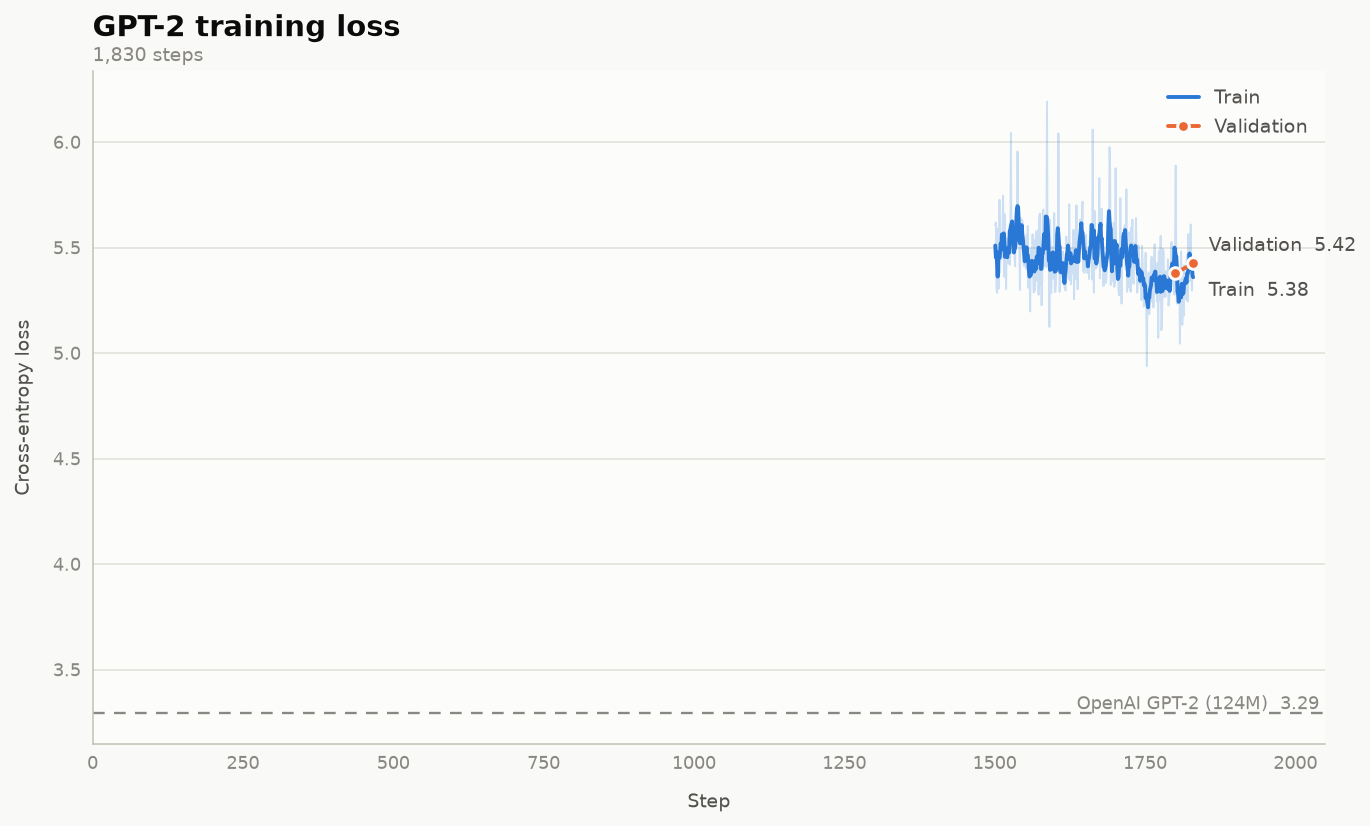

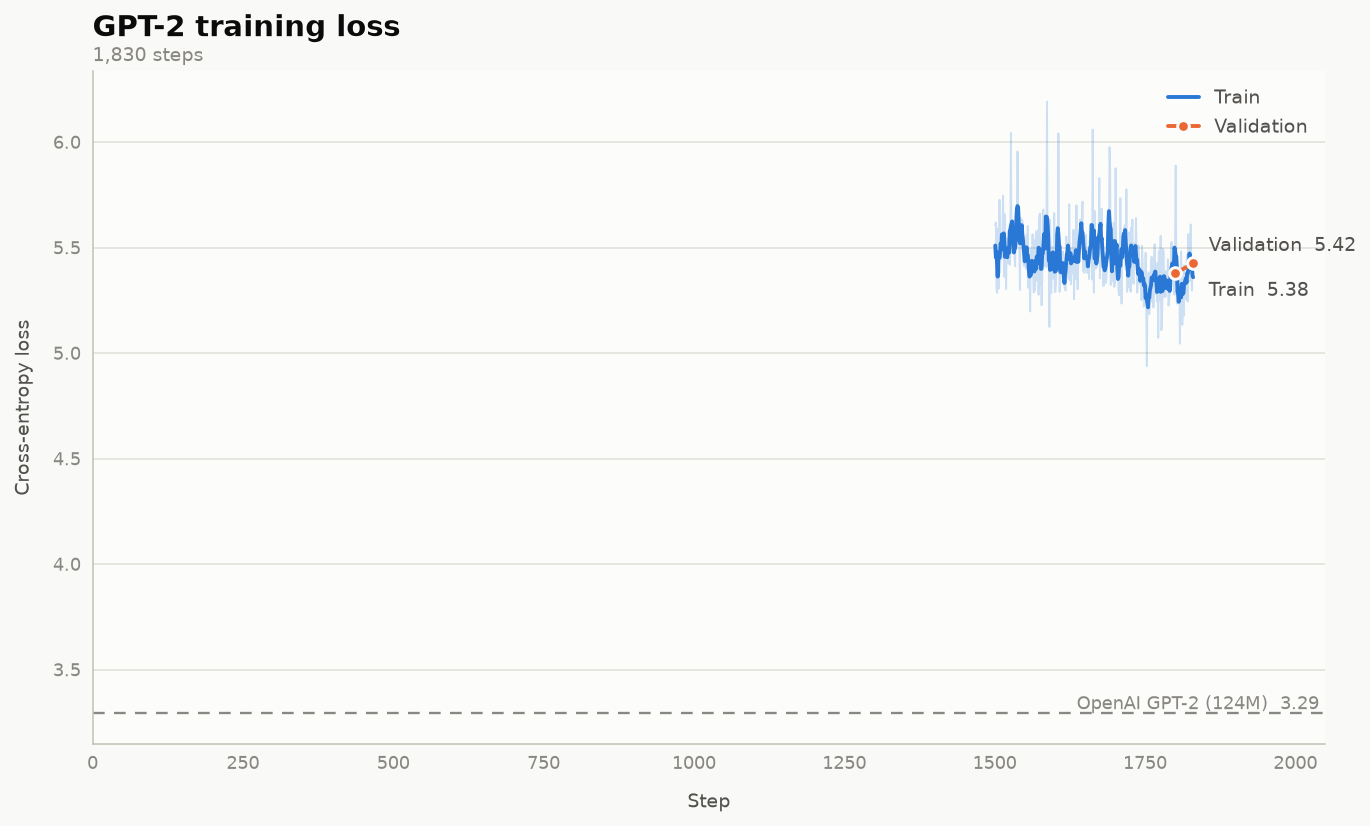

In [12]:
fig = P.plot(*data, theme='light')   # theme='dark' for the dark version
fig

## The numbers

Every plotted value, readable without squinting at pixels.

In [13]:
P.summarize(*data)

series            step      loss
--------------------------------
train  first     1,501    5.6044
train  last      1,830    5.3779
train  best      1,753    4.9375
val    last      1,830    5.4248
val    best      1,800    5.3774
--------------------------------
gap to GPT-2             +2.0850


## Earlier renders

`log.txt` was truncated when the run resumed from a checkpoint, so the current
log starts at step 1501. The front half of the run survives only as an image —
the 11.0 → 7.0 drop over the first 250 steps is the interesting part.

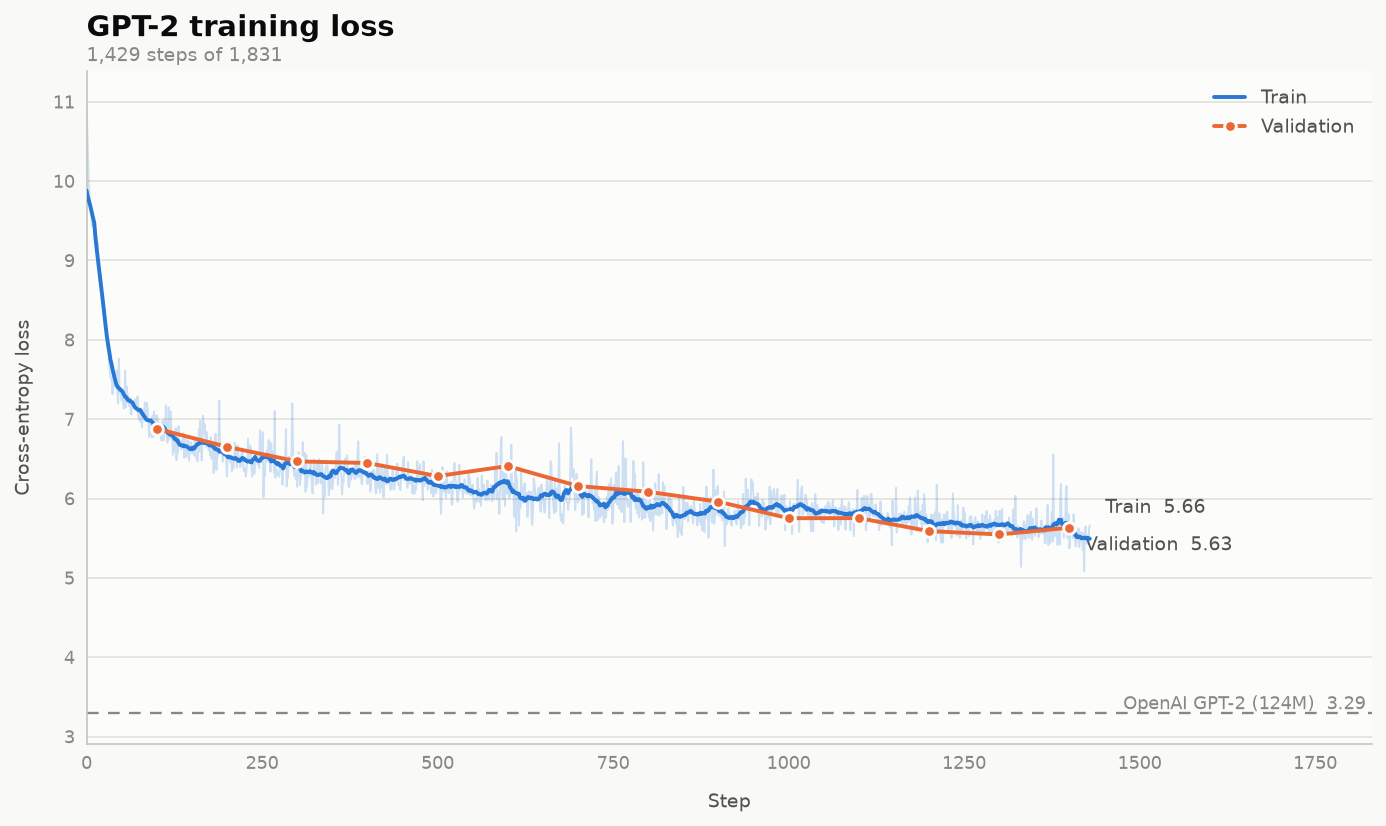

In [14]:
from IPython.display import Image, display

earlier = os.path.join(REPO, 'runs', 'loss_light.png')   # steps 0-1429, rendered before the restart
if os.path.exists(earlier):
    display(Image(filename=earlier))
else:
    print(f'{earlier} not found')

## Comparing runs

For tomorrow's smaller `n_layer=6, n_embd=384` run: point `read_log` at each
run's log and overlay the val curves on one axis. Same data, same tokenizer,
so the only difference is how the compute was allocated.

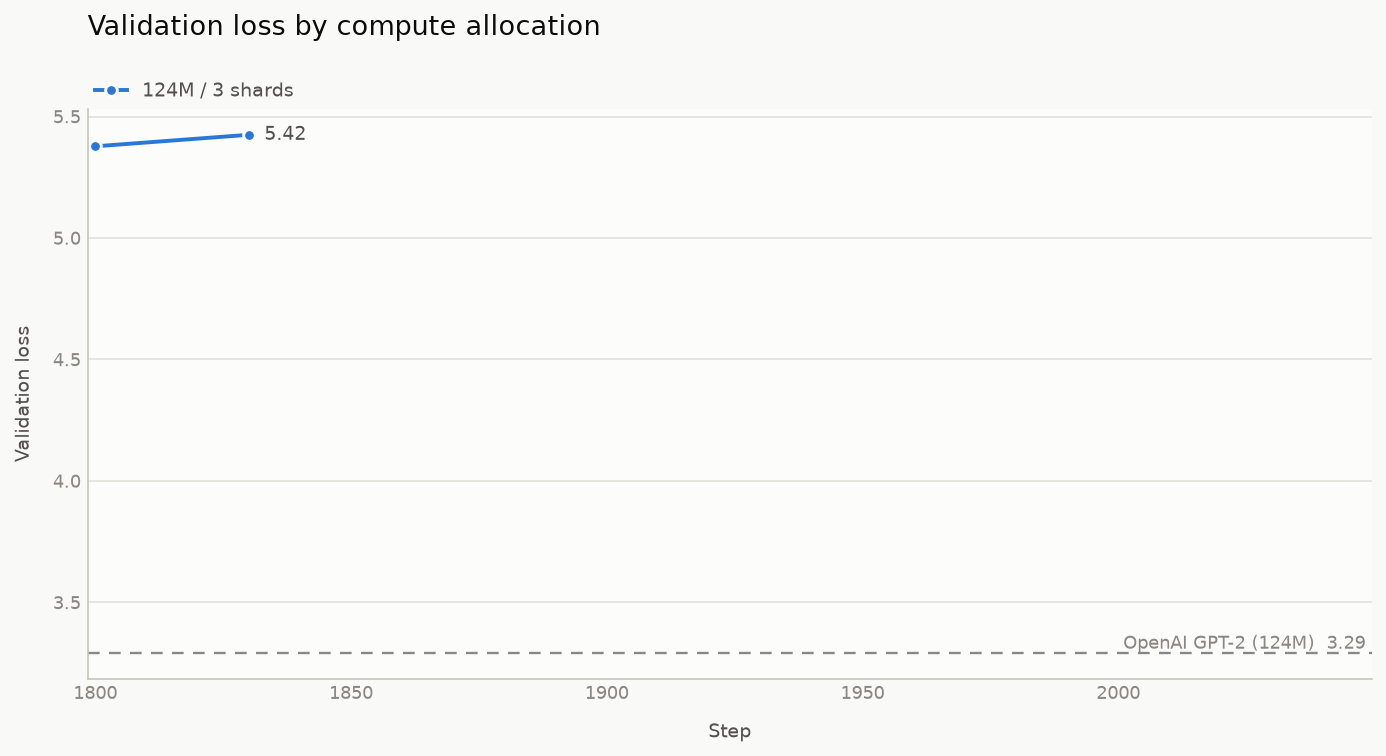

In [15]:
import matplotlib.pyplot as plt

RUNS = {
    '124M / 3 shards': os.path.join(REPO, 'runs', 'log_full.txt'),
    # '30M / 12 shards': os.path.join(REPO, 'runs_small', 'log.txt'),
}

c = P.THEMES['light']
hues = [c['train'], c['val']]   # slots 1 and 2, CVD-validated

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=140)
fig.patch.set_facecolor(c['page'])
ax.set_facecolor(c['surface'])
ax.grid(axis='y', color=c['grid'], linewidth=0.8)
ax.set_axisbelow(True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
for s in ('left', 'bottom'):
    ax.spines[s].set_color(c['axis'])
ax.tick_params(colors=c['muted'], labelsize=9, length=0)

last_step = 0
for (name, path), hue in zip(RUNS.items(), hues):
    if not os.path.exists(path):
        print(f'skipping {name}: no {path}')
        continue
    _, _, vs, vl = P.read_log(path)
    if len(vs):
        ax.plot(vs, vl, color=hue, linewidth=2.0, marker='o', markersize=6,
                markeredgecolor=c['surface'], markeredgewidth=1.5, label=name)
        ax.annotate(f'{vl[-1]:.2f}', xy=(vs[-1], vl[-1]), xytext=(8, 0),
                    textcoords='offset points', va='center', fontsize=10, color=c['ink2'])
        last_step = max(last_step, vs[-1])

ax.axhline(P.GPT2_124M_BASELINE, color=c['muted'], linewidth=1.2, linestyle=(0, (5, 4)))
ax.text(0.995, P.GPT2_124M_BASELINE, f'  OpenAI GPT-2 (124M)  {P.GPT2_124M_BASELINE:.2f}',
        transform=ax.get_yaxis_transform(), ha='right', va='bottom', fontsize=9, color=c['muted'])

ax.set_xlim(right=last_step * 1.12)     # room for the endpoint labels
ax.set_xlabel('Step', fontsize=10, color=c['ink2'], labelpad=10)
ax.set_ylabel('Validation loss', fontsize=10, color=c['ink2'], labelpad=10)
ax.set_title('Validation loss by compute allocation', fontsize=14, color=c['ink'], loc='left', pad=38)

# the legend goes in a row above the plot: inside the axes it collides with either
# the endpoint labels (upper right) or the GPT-2 baseline (lower left)
leg = ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), ncol=max(1, len(RUNS)),
                frameon=False, fontsize=10, handlelength=1.6, borderaxespad=0)
for t in leg.get_texts():
    t.set_color(c['ink2'])
fig.tight_layout()